# Rastros del 36
## Análisis de víctimas mortales de la Guerra Civil en Euskadi
**Fuente:** Open Data Euskadi — Gobierno Vasco  
**Autora:** Marisa Lozano Arroyo
**Proyecto:** Big Data aplicado a la Memoria Histórica de España

---

Este notebook forma parte del proyecto *Rastros del 36*, una plataforma 
de memoria histórica que cruza datos de represión franquista y exilio 
republicano en España.

En esta primera fase analizamos el dataset de víctimas mortales de la 
Guerra Civil en Euskadi: más de 21.000 registros nominales con información 
biográfica, profesional, política y geográfica de cada persona.

**Objetivo:** explorar quiénes eran estas personas, de dónde venían, 
qué hacían, qué militancia tenían y dónde murieron.



In [2]:
# Librerías de manipulación y análisis de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

# Para no ver warnings innecesarios
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [3]:
# Carga del dataset
df = pd.read_excel('victimas_guerra_civil.xlsx')

# Primera exploración
print(f"✅ Dataset cargado correctamente")
print(f"📊 Filas: {df.shape[0]:,}")
print(f"📋 Columnas: {df.shape[1]}")
print(f"\n--- NOMBRES DE COLUMNAS ---")
for i, col in enumerate(df.columns, 1):
    print(f"{i:02d}. {col}")

✅ Dataset cargado correctamente
📊 Filas: 21,367
📋 Columnas: 22

--- NOMBRES DE COLUMNAS ---
01. Apellidos
02. Nombre
03. Provincia nacimiento
04. Municipio nacimiento
05. Fecha nacimiento
06. Edad
07. Provincia domicilio
08. Municipio domicilio
09. Estado civil
10. Num. hijos
11. Nombre hijos
12. Profesión
13. Filiación política/social
14. Batallón
15. Causa muerte
16. Fecha fallecimiento
17. Lugar fallecimiento
18. Provincia fallecimiento
19. Municipio fallecimiento
20. Lugar inhumación
21. Fuentes
22. Biografía


## 1. Exploración y calidad del dato

Antes de analizar, necesitamos entender qué tan completo está el dataset.
En archivística esto equivale a evaluar el estado de conservación de un fondo:
¿qué información se conserva?, ¿qué se ha perdido?, ¿qué está incompleto?

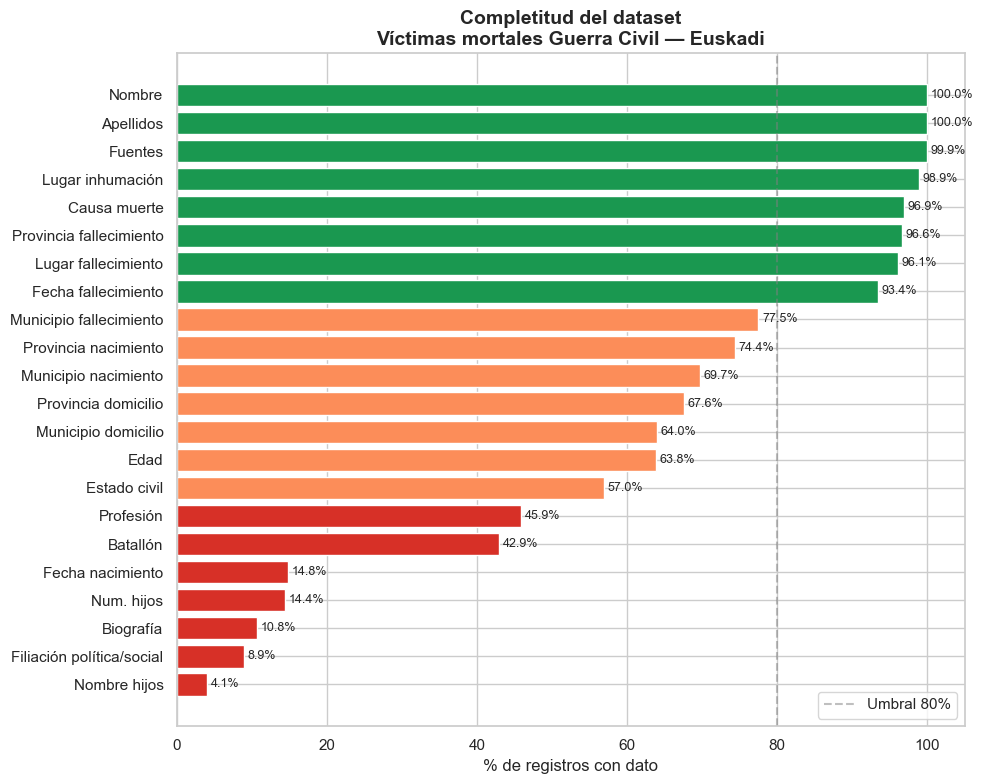

In [4]:
# Porcentaje de valores rellenos por columna
completitud = (df.notna().sum() / len(df) * 100).sort_values(ascending=True)

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(completitud.index, completitud.values, color=['#d73027' if v < 50 else '#fc8d59' if v < 80 else '#1a9850' for v in completitud.values])

ax.set_xlabel('% de registros con dato', fontsize=12)
ax.set_title('Completitud del dataset\nVíctimas mortales Guerra Civil — Euskadi', fontsize=14, fontweight='bold')
ax.axvline(x=80, color='gray', linestyle='--', alpha=0.5, label='Umbral 80%')
ax.legend()

for bar, val in zip(bars, completitud.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Reflexión sobre la calidad del dato

El gráfico revela un patrón significativo desde el punto de vista archivístico:
los datos relativos a la **muerte** (causa, lugar, fecha) están mucho mejor 
conservados que los datos sobre la **vida** (nacimiento, profesión, familia).

Esto refleja la naturaleza de las fuentes primarias utilizadas: registros de 
defunción, expedientes judiciales y listas de fusilados documentan el final, 
mientras que la información biográfica previa depende de fuentes más dispersas 
y fragmentadas.

Trabajaremos principalmente con las columnas con más del 60% de completitud.

## 2. ¿Cómo murieron?

Analizamos las causas de muerte registradas en el dataset.
Esta información procede principalmente de expedientes judiciales,
registros de defunción y testimonios recogidos por asociaciones de memoria histórica.

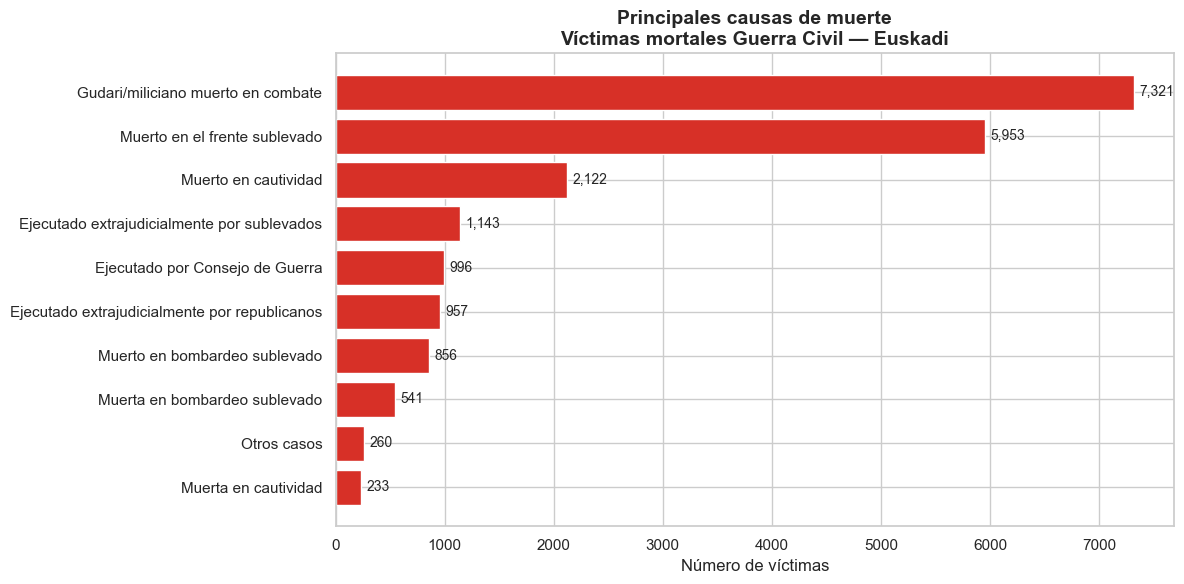


--- TOP 10 CAUSAS DE MUERTE ---
Causa muerte
Gudari/miliciano muerto en combate               7321
Muerto en el frente sublevado                    5953
Muerto en cautividad                             2122
Ejecutado extrajudicialmente por sublevados      1143
Ejecutado por Consejo de Guerra                   996
Ejecutado extrajudicialmente por republicanos     957
Muerto en bombardeo sublevado                     856
Muerta en bombardeo sublevado                     541
Otros casos                                       260
Muerta en cautividad                              233


In [5]:
# Frecuencia de causas de muerte
causas = df['Causa muerte'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(causas.index[::-1], causas.values[::-1], color='#d73027')

ax.set_xlabel('Número de víctimas', fontsize=12)
ax.set_title('Principales causas de muerte\nVíctimas mortales Guerra Civil — Euskadi', 
             fontsize=14, fontweight='bold')

for bar, val in zip(bars, causas.values[::-1]):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, 
            f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Tabla resumen
print("\n--- TOP 10 CAUSAS DE MUERTE ---")
print(causas.to_string())

### Nota metodológica

El dataset recoge **todas las muertes violentas** del conflicto, no solo 
las víctimas de la represión franquista. Esto es una decisión archivística 
relevante: permite una visión completa del coste humano de la guerra,
pero requiere distinguir entre tipos de violencia al analizar los datos.

Para las fases siguientes del proyecto, trabajaremos con dos subconjuntos:
- **Represión franquista:** ejecutados, muertos en cautividad
- **Combatientes:** muertos en combate en ambos bandos

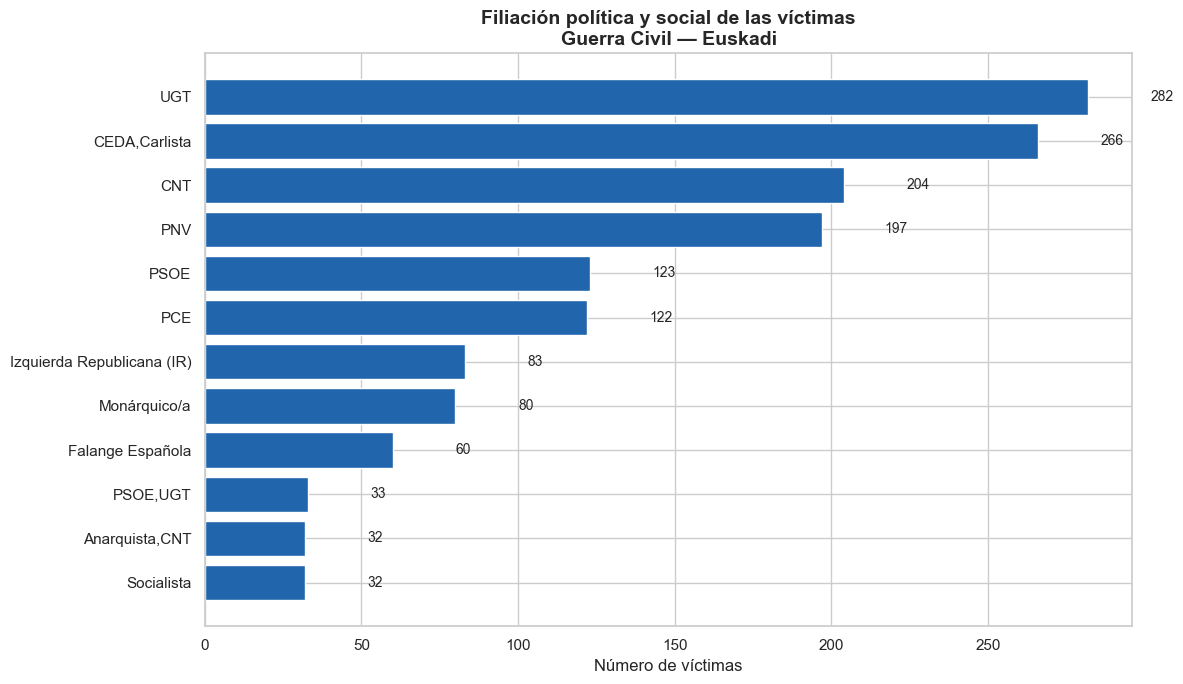

In [6]:
# Filiación política de las víctimas
filiacion = df['Filiación política/social'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(filiacion.index[::-1], filiacion.values[::-1], color='#2166ac')

ax.set_xlabel('Número de víctimas', fontsize=12)
ax.set_title('Filiación política y social de las víctimas\nGuerra Civil — Euskadi', 
             fontsize=14, fontweight='bold')

for bar, val in zip(bars, filiacion.values[::-1]):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Lectura histórica de la filiación política

La presencia de organizaciones de ambos bandos confirma que el dataset 
recoge el conflicto en toda su complejidad. Destacan varios elementos:

- La **militancia sindical** (UGT, CNT) supera a la militancia partidista,
  lo que refleja la centralidad del movimiento obrero en el conflicto vasco.
- El **PNV** tiene una presencia significativa, recordando que el nacionalismo
  vasco católico se alineó con la República frente al franquismo.
- La presencia de **CEDA, Carlistas, Falange y Monárquicos** muestra víctimas
  del bando sublevado, principalmente por represión republicana o combate.

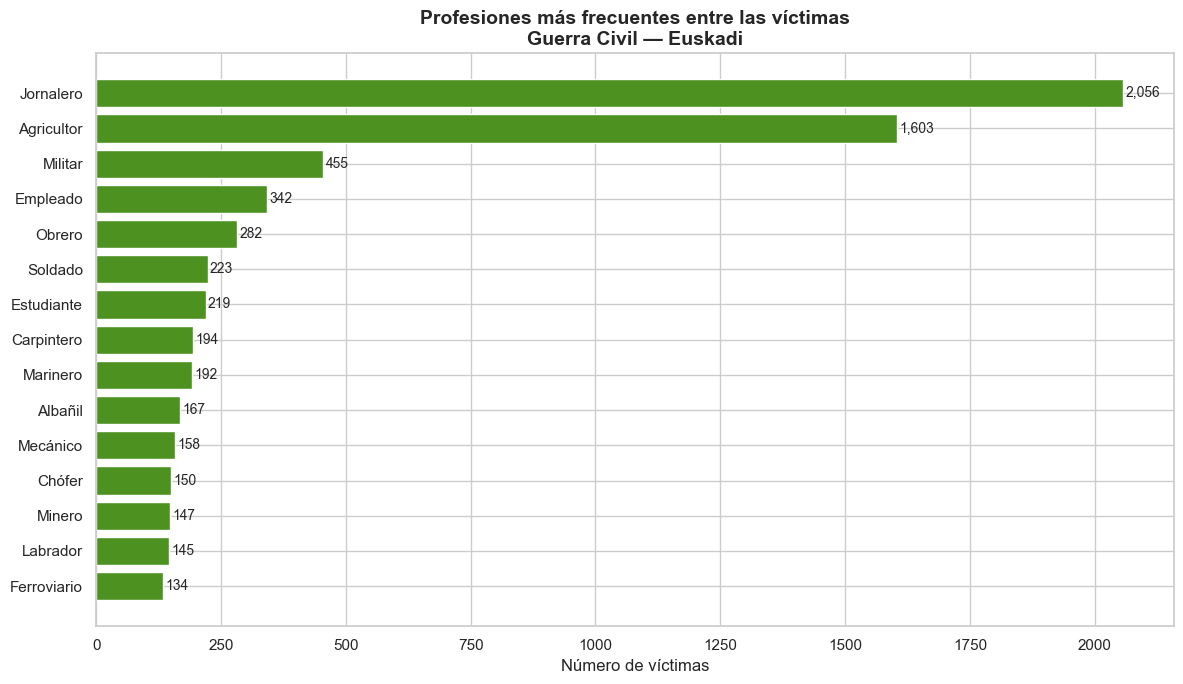

In [7]:
# Profesiones más frecuentes
profesiones = df['Profesión'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(profesiones.index[::-1], profesiones.values[::-1], color='#4d9221')

ax.set_xlabel('Número de víctimas', fontsize=12)
ax.set_title('Profesiones más frecuentes entre las víctimas\nGuerra Civil — Euskadi',
             fontsize=14, fontweight='bold')

for bar, val in zip(bars, profesiones.values[::-1]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Perfil sociológico de las víctimas

Las profesiones confirman que la guerra tuvo un coste humano 
desproporcionado entre las **clases trabajadoras y el mundo rural**:
jornaleros y agricultores representan casi el 40% de las víctimas 
con profesión registrada.

La presencia de oficios industriales (carpintero, albañil, mecánico, 
minero, ferroviario) refleja la fuerte implantación del movimiento 
obrero en el País Vasco industrial, coherente con el peso de UGT y CNT 
observado en la filiación política.

El dato de **219 estudiantes** señala la movilización de una generación 
joven que no llegó a desarrollar su vida profesional.

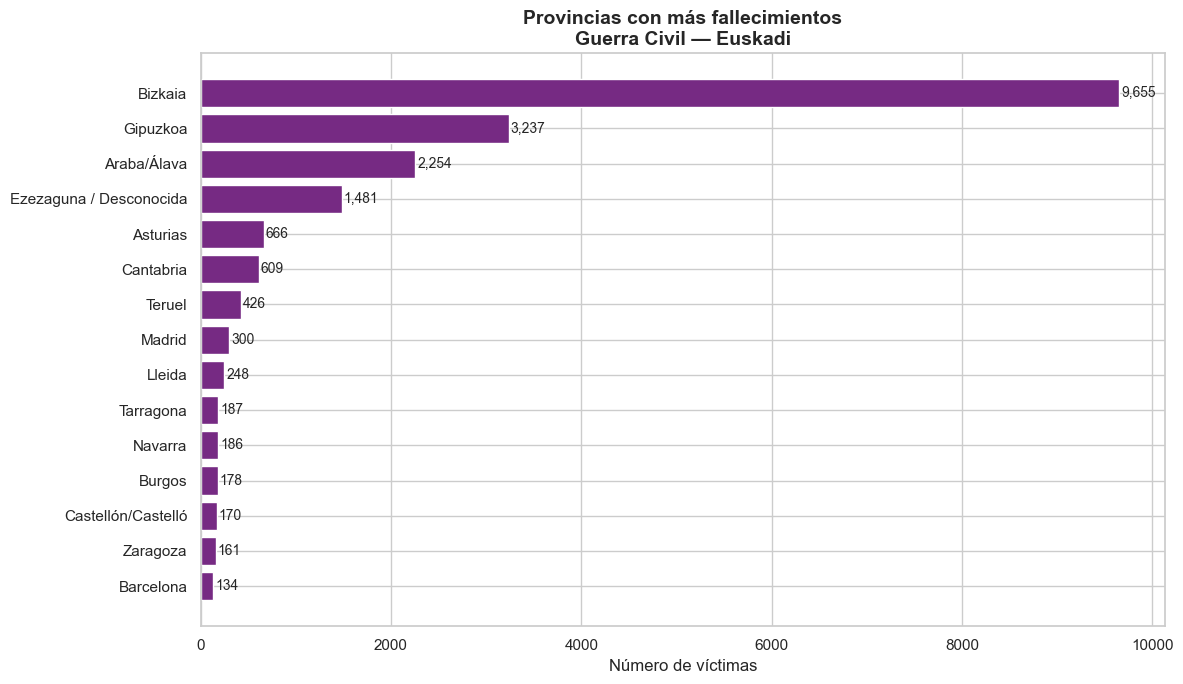

In [8]:
# Víctimas por provincia de fallecimiento
prov_fall = df['Provincia fallecimiento'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(prov_fall.index[::-1], prov_fall.values[::-1], color='#762a83')

ax.set_xlabel('Número de víctimas', fontsize=12)
ax.set_title('Provincias con más fallecimientos\nGuerra Civil — Euskadi',
             fontsize=14, fontweight='bold')

for bar, val in zip(bars, prov_fall.values[::-1]):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Geografía de la muerte

Bizkaia concentra casi la mitad de los fallecimientos del dataset, 
reflejo de que fue el último territorio vasco en caer ante las tropas 
franquistas (junio 1937) y el escenario de los combates más prolongados.

La presencia de provincias alejadas como Teruel, Lleida o Tarragona 
evidencia que muchos combatientes vascos lucharon en otros frentes 
de la guerra, siguiendo el repliegue republicano hasta el final.

Los **1.481 registros sin provincia conocida** representan un reto 
archivístico pendiente: personas cuyo lugar de muerte no ha podido 
documentarse todavía.

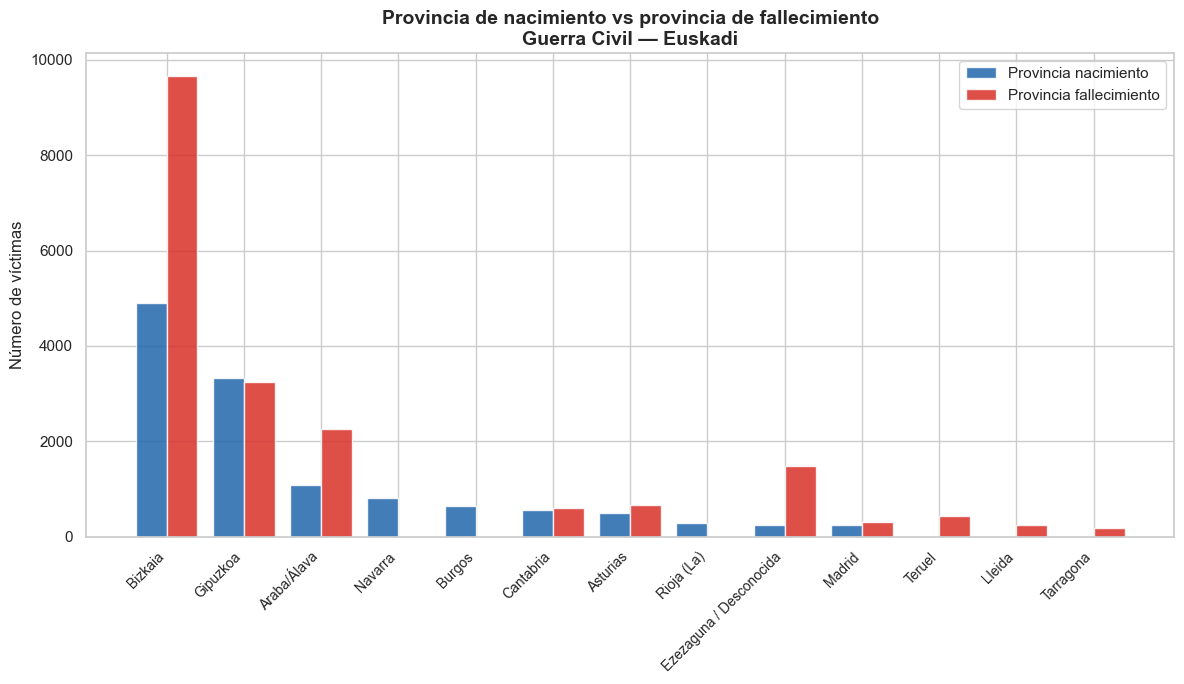

In [9]:
# Comparativa nacimiento vs fallecimiento por provincia
nac = df['Provincia nacimiento'].value_counts().head(10).rename('Nacimiento')
fall = df['Provincia fallecimiento'].value_counts().head(10).rename('Fallecimiento')

comparativa = pd.DataFrame([nac, fall]).T.fillna(0)

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(comparativa))
width = 0.4

ax.bar([i - width/2 for i in x], comparativa['Nacimiento'], 
       width=width, label='Provincia nacimiento', color='#2166ac', alpha=0.85)
ax.bar([i + width/2 for i in x], comparativa['Fallecimiento'], 
       width=width, label='Provincia fallecimiento', color='#d73027', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(comparativa.index, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Número de víctimas', fontsize=12)
ax.set_title('Provincia de nacimiento vs provincia de fallecimiento\nGuerra Civil — Euskadi',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### El desplazamiento de la guerra

Este gráfico visualiza uno de los fenómenos más dolorosos del conflicto:
las personas no murieron donde nacieron.

Bizkaia recibió casi el doble de muertes que nacimientos registrados,
evidenciando la llegada de combatientes de otras provincias a defender
el último bastión republicano del norte.

Madrid concentra fallecimientos de vascos que siguieron el repliegue
republicano hacia el centro y el este peninsular, combatiendo lejos
de su tierra hasta el final de la guerra.

Este patrón de desplazamiento es el puente directo hacia la siguiente
fase del proyecto: muchos de quienes sobrevivieron continuaron ese
movimiento hasta cruzar la frontera — el exilio.

## 3. Mapa interactivo de fallecimientos

Visualizamos geográficamente dónde murieron las víctimas.
Para ello geolocalicemos las provincias de fallecimiento
y representamos el volumen de muertes por ubicación.

In [10]:
# Instalamos folium si no está disponible
try:
    import folium
    print("✅ Folium ya está instalado")
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'folium'], capture_output=True)
    import folium
    print("✅ Folium instalado correctamente")

from folium.plugins import HeatMap
print(f"📍 Versión de Folium: {folium.__version__}")

✅ Folium ya está instalado
📍 Versión de Folium: 0.20.0


In [11]:
# Coordenadas de provincias españolas
coordenadas = {
    'Araba/Álava': (42.8469, -2.6727),
    'Albacete': (38.9942, -1.8564),
    'Alicante/Alacant': (38.3452, -0.4810),
    'Almería': (36.8340, -2.4637),
    'Asturias': (43.3614, -5.8593),
    'Ávila': (40.6566, -4.6818),
    'Badajoz': (38.8794, -6.9706),
    'Barcelona': (41.3851, 2.1734),
    'Bizkaia': (43.2630, -2.9350),
    'Burgos': (42.3440, -3.6969),
    'Cáceres': (39.4752, -6.3724),
    'Cádiz': (36.5271, -6.2886),
    'Cantabria': (43.1828, -3.9878),
    'Castellón/Castelló': (39.9864, -0.0513),
    'Ciudad Real': (38.9848, -3.9274),
    'Córdoba': (37.8882, -4.7794),
    'Gipuzkoa': (43.3128, -1.9754),
    'Granada': (37.1773, -3.5986),
    'Guadalajara': (40.6330, -3.1669),
    'Huelva': (37.2614, -6.9447),
    'Huesca': (42.1401, -0.4089),
    'Jaén': (37.7796, -3.7849),
    'La Rioja': (42.2871, -2.5396),
    'Rioja (La)': (42.2871, -2.5396),
    'Las Palmas': (28.1235, -15.4363),
    'León': (42.5987, -5.5671),
    'Lleida': (41.6176, 0.6200),
    'Lugo': (43.0097, -7.5567),
    'Madrid': (40.4168, -3.7038),
    'Málaga': (36.7213, -4.4213),
    'Murcia': (37.9922, -1.1307),
    'Navarra': (42.6954, -1.6761),
    'Ourense': (42.3359, -7.8639),
    'Palencia': (42.0096, -4.5288),
    'Pontevedra': (42.4310, -8.6444),
    'Salamanca': (40.9701, -5.6635),
    'Segovia': (40.9429, -4.1088),
    'Sevilla': (37.3891, -5.9845),
    'Soria': (41.7640, -2.4790),
    'Tarragona': (41.1189, 1.2445),
    'Teruel': (40.3456, -1.1065),
    'Toledo': (39.8628, -4.0273),
    'Valencia/València': (39.4699, -0.3763),
    'Valladolid': (41.6523, -4.7245),
    'Zamora': (41.5034, -5.7467),
    'Zaragoza': (41.6561, -0.8773),
}

print(f"✅ {len(coordenadas)} provincias georreferenciadas")

✅ 46 provincias georreferenciadas


In [12]:
# Agrupamos víctimas por provincia de fallecimiento
muertes_prov = df['Provincia fallecimiento'].value_counts().reset_index()
muertes_prov.columns = ['Provincia', 'Victimas']

# Añadimos coordenadas
muertes_prov['lat'] = muertes_prov['Provincia'].map(lambda x: coordenadas.get(x, (None, None))[0])
muertes_prov['lon'] = muertes_prov['Provincia'].map(lambda x: coordenadas.get(x, (None, None))[1])

# Eliminamos filas sin coordenadas
muertes_geo = muertes_prov.dropna(subset=['lat', 'lon'])
print(f"✅ {len(muertes_geo)} provincias con coordenadas")
print(f"⚠️  {len(muertes_prov) - len(muertes_geo)} provincias sin coordenadas (desconocidas o extranjeras)")

# Creamos el mapa base centrado en España
mapa = folium.Map(location=[40.4168, -3.7038], zoom_start=6, 
                  tiles='CartoDB positron')

# Añadimos círculos proporcionales al número de víctimas
for _, row in muertes_geo.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=float(row['Victimas']) / 150,
        color='#d73027',
        fill=True,
        fill_color='#d73027',
        fill_opacity=0.6,
        popup=folium.Popup(
            f"<b>{row['Provincia']}</b><br>Víctimas: {row['Victimas']:,}",
            max_width=200
        ),
        tooltip=f"{row['Provincia']}: {row['Victimas']:,} víctimas"
    ).add_to(mapa)

# Añadimos título
titulo = '''
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background-color: white; padding: 10px 20px;
     border-radius: 8px; border: 2px solid #d73027;
     font-family: Arial; font-size: 14px; font-weight: bold; text-align: center;">
     🗺️ Rastros del 36 · Víctimas por provincia de fallecimiento<br>
     <span style="font-size:11px; font-weight:normal;">Guerra Civil — Euskadi | Fuente: Open Data Euskadi</span>
</div>'''
mapa.get_root().html.add_child(folium.Element(titulo))

# Guardamos y mostramos
mapa.save('mapa_victimas_euskadi.html')
print("✅ Mapa guardado como 'mapa_victimas_euskadi.html'")
print("📍 Haz clic en los círculos para ver el número de víctimas por provincia")

mapa

✅ 42 provincias con coordenadas
⚠️  16 provincias sin coordenadas (desconocidas o extranjeras)
✅ Mapa guardado como 'mapa_victimas_euskadi.html'
📍 Haz clic en los círculos para ver el número de víctimas por provincia


In [13]:
# Verificamos las top 5 provincias y sus coordenadas
top5 = muertes_geo.head(5)
for _, row in top5.iterrows():
    print(f"{row['Provincia']:30} | Víctimas: {row['Victimas']:5} | lat: {row['lat']} | lon: {row['lon']}")

Bizkaia                        | Víctimas:  9655 | lat: 43.263 | lon: -2.935
Gipuzkoa                       | Víctimas:  3237 | lat: 43.3128 | lon: -1.9754
Araba/Álava                    | Víctimas:  2254 | lat: 42.8469 | lon: -2.6727
Asturias                       | Víctimas:   666 | lat: 43.3614 | lon: -5.8593
Cantabria                      | Víctimas:   609 | lat: 43.1828 | lon: -3.9878


In [14]:
# Recreamos el mapa con mejor escala
mapa2 = folium.Map(location=[42.5, -2.5], zoom_start=7,
                   tiles='CartoDB positron')

# Escala logarítmica para que los círculos sean proporcionales pero no gigantes
import numpy as np

for _, row in muertes_geo.iterrows():
    radio = np.log1p(row['Victimas']) * 3  # escala logarítmica

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radio,
        color='#d73027',
        fill=True,
        fill_color='#d73027',
        fill_opacity=0.6,
        popup=folium.Popup(
            f"<b>{row['Provincia']}</b><br>Víctimas: {row['Victimas']:,}",
            max_width=200
        ),
        tooltip=f"{row['Provincia']}: {row['Victimas']:,} víctimas"
    ).add_to(mapa2)

# Título
titulo = '''
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background-color: white; padding: 10px 20px;
     border-radius: 8px; border: 2px solid #d73027;
     font-family: Arial; font-size: 14px; font-weight: bold; text-align: center;">
     🗺️ Rastros del 36 · Víctimas por provincia de fallecimiento<br>
     <span style="font-size:11px; font-weight:normal;">
     Guerra Civil — Euskadi | Fuente: Open Data Euskadi</span>
</div>'''
mapa2.get_root().html.add_child(folium.Element(titulo))

mapa2.save('mapa_victimas_euskadi.html')
print("✅ Mapa corregido guardado")
mapa2

✅ Mapa corregido guardado


## 4. Conclusiones de la Fase 1

El análisis de las **21.367 víctimas mortales** de la Guerra Civil en Euskadi
revela un retrato sociológico e histórico de gran precisión:

### Quiénes eran
Las víctimas eran mayoritariamente **hombres de clase trabajadora y mundo rural**:
jornaleros, agricultores, obreros industriales. Su militancia sindical (UGT, CNT)
y política (PNV, PSOE, PCE) refleja la estructura social del País Vasco de los años 30.

### Cómo murieron
La mayoría murió en combate, pero más de **4.000 personas fueron ejecutadas**
— extrajudicialmente o por Consejo de Guerra — o murieron en cautividad.
La distinción entre muerte en combate y represión es fundamental
para entender la naturaleza del conflicto.

### Dónde murieron
Bizkaia concentró casi la mitad de los fallecimientos, reflejo de ser
el último territorio vasco en caer. Pero vascos murieron en toda España:
en Madrid, en Teruel, en Lleida, siguiendo el repliegue republicano.

### Lo que los datos no dicen
El 36% de los registros carece de provincia de nacimiento.
Profesión y filiación política están incompletas en más del 40% de los casos.
Estos vacíos no son errores: son la huella del silencio impuesto durante décadas.

---

## Próximos pasos — Fase 2

- Incorporar datasets de otras comunidades autónomas (Andalucía, Castilla y León, Valencia)
- Cruzar con registros del exilio republicano
- Construir el modelo de datos relacional completo
- Aplicar NLP para extraer información de los campos de texto libre (Biografía, Fuentes)

---

*Proyecto Rastros del 36 · Big Data aplicado a la Memoria Histórica de España*  
*Fase 1 completada — [fecha]*

In [15]:
print("=" * 55)
print("   RASTROS DEL 36 · RESUMEN FASE 1")
print("=" * 55)
print(f"\n📊 Total víctimas analizadas:     {len(df):>8,}")
print(f"📋 Variables por registro:        {df.shape[1]:>8}")
print(f"\n✅ Campos con >80% completitud:   {(df.notna().sum()/len(df)>0.8).sum():>8}")
print(f"⚠️  Campos con 50-80% completitud: {((df.notna().sum()/len(df)>=0.5) & (df.notna().sum()/len(df)<=0.8)).sum():>8}")
print(f"🔴 Campos con <50% completitud:   {(df.notna().sum()/len(df)<0.5).sum():>8}")

print(f"\n⚔️  Muertos en combate:            {df['Causa muerte'].str.contains('combate|frente', case=False, na=False).sum():>8,}")
print(f"🔫 Ejecutados:                    {df['Causa muerte'].str.contains('ejecutad', case=False, na=False).sum():>8,}")
print(f"⛓️  Muertos en cautividad:         {df['Causa muerte'].str.contains('cautividad', case=False, na=False).sum():>8,}")
print(f"💣 Muertos en bombardeo:          {df['Causa muerte'].str.contains('bombardeo', case=False, na=False).sum():>8,}")

print(f"\n🗺️  Provincias de fallecimiento:   {df['Provincia fallecimiento'].nunique():>8}")
print(f"💼 Profesiones distintas:         {df['Profesión'].nunique():>8}")
print(f"🏛️  Filiaciones políticas:         {df['Filiación política/social'].nunique():>8}")
print("\n" + "=" * 55)
print("   Fuente: Open Data Euskadi — Gobierno Vasco")
print("=" * 55)

   RASTROS DEL 36 · RESUMEN FASE 1

📊 Total víctimas analizadas:       21,367
📋 Variables por registro:              22

✅ Campos con >80% completitud:          8
⚠️  Campos con 50-80% completitud:        7
🔴 Campos con <50% completitud:          7

⚔️  Muertos en combate:              13,320
🔫 Ejecutados:                       3,202
⛓️  Muertos en cautividad:            2,355
💣 Muertos en bombardeo:             1,471

🗺️  Provincias de fallecimiento:         58
💼 Profesiones distintas:              300
🏛️  Filiaciones políticas:              109

   Fuente: Open Data Euskadi — Gobierno Vasco


## 4. Conclusiones de la Fase 1

El análisis de las **21.367 víctimas mortales** de la Guerra Civil en Euskadi
revela un retrato sociológico e histórico de gran precisión:

### Quiénes eran
Las víctimas eran mayoritariamente **hombres de clase trabajadora y mundo rural**:
jornaleros, agricultores, obreros industriales. Su militancia sindical (UGT, CNT)
y política (PNV, PSOE, PCE) refleja la estructura social del País Vasco de los años 30.

### Cómo murieron
La mayoría murió en combate, pero más de **4.000 personas fueron ejecutadas**
— extrajudicialmente o por Consejo de Guerra — o murieron en cautividad.
La distinción entre muerte en combate y represión es fundamental
para entender la naturaleza del conflicto.

### Dónde murieron
Bizkaia concentró casi la mitad de los fallecimientos, reflejo de ser
el último territorio vasco en caer. Pero vascos murieron en toda España:
en Madrid, en Teruel, en Lleida, siguiendo el repliegue republicano.

### Lo que los datos no dicen
El 36% de los registros carece de provincia de nacimiento.
Profesión y filiación política están incompletas en más del 40% de los casos.
Estos vacíos no son errores: son la huella del silencio impuesto durante décadas.

---

## Próximos pasos — Fase 2

- Incorporar datasets de otras comunidades autónomas (Andalucía, Castilla y León, Valencia)
- Cruzar con registros del exilio republicano
- Construir el modelo de datos relacional completo
- Aplicar NLP para extraer información de los campos de texto libre (Biografía, Fuentes)

---

*Proyecto Rastros del 36 · Big Data aplicado a la Memoria Histórica de España*  
*Fase 1 completada — [fecha]*

In [17]:
print("=" * 55)
print("   RASTROS DEL 36 · RESUMEN FASE 1")
print("=" * 55)
print(f"\n📊 Total víctimas analizadas:     {len(df):>8,}")
print(f"📋 Variables por registro:        {df.shape[1]:>8}")
print(f"\n✅ Campos con >80% completitud:   {(df.notna().sum()/len(df)>0.8).sum():>8}")
print(f"⚠️  Campos con 50-80% completitud: {((df.notna().sum()/len(df)>=0.5) & (df.notna().sum()/len(df)<=0.8)).sum():>8}")
print(f"🔴 Campos con <50% completitud:   {(df.notna().sum()/len(df)<0.5).sum():>8}")

print(f"\n⚔️  Muertos en combate:            {df['Causa muerte'].str.contains('combate|frente', case=False, na=False).sum():>8,}")
print(f"🔫 Ejecutados:                    {df['Causa muerte'].str.contains('ejecutad', case=False, na=False).sum():>8,}")
print(f"⛓️  Muertos en cautividad:         {df['Causa muerte'].str.contains('cautividad', case=False, na=False).sum():>8,}")
print(f"💣 Muertos en bombardeo:          {df['Causa muerte'].str.contains('bombardeo', case=False, na=False).sum():>8,}")

print(f"\n🗺️  Provincias de fallecimiento:   {df['Provincia fallecimiento'].nunique():>8}")
print(f"💼 Profesiones distintas:         {df['Profesión'].nunique():>8}")
print(f"🏛️  Filiaciones políticas:         {df['Filiación política/social'].nunique():>8}")
print("\n" + "=" * 55)
print("   Fuente: Open Data Euskadi — Gobierno Vasco")
print("=" * 55)

   RASTROS DEL 36 · RESUMEN FASE 1

📊 Total víctimas analizadas:       21,367
📋 Variables por registro:              22

✅ Campos con >80% completitud:          8
⚠️  Campos con 50-80% completitud:        7
🔴 Campos con <50% completitud:          7

⚔️  Muertos en combate:              13,320
🔫 Ejecutados:                       3,202
⛓️  Muertos en cautividad:            2,355
💣 Muertos en bombardeo:             1,471

🗺️  Provincias de fallecimiento:         58
💼 Profesiones distintas:              300
🏛️  Filiaciones políticas:              109

   Fuente: Open Data Euskadi — Gobierno Vasco
